In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
import sys
print("at directory:", os.getcwd())
print("changing to root directory")
os.chdir("..")
print("at directory:", os.getcwd())

at directory: /Users/wilka/git/research/human-dyna-web/analysis_notebooks
changing to root directory
at directory: /Users/wilka/git/research/human-dyna-web


In [4]:
# !pip install -e libraries/housemaze -e libraries/nicewebrl -e libraries/jaxneurorl -r requirements.txt

In [5]:
import jax
import jax.numpy as jnp
import functools
from functools import partial
import numpy as np
from pprint import pprint
import glob
from glob import glob
import matplotlib.pyplot as plt
import polars as pl
from tqdm.notebook import tqdm


from housemaze.human_dyna import mazes
from housemaze import renderer
from housemaze import utils
from housemaze.human_dyna import multitask_env as maze
from housemaze.human_dyna import experiments as housemaze_experiments

from jaxneurorl import launcher

from simulations import housemaze_trainer
from analysis import data_loading
from analysis import download_data
from analysis import housemaze as housemaze_analysis
from analysis import plots
from nicewebrl import dataframe 

from nicewebrl import dataframe

from experiment_utils import SuccessTrackingAutoResetWrapper


In [6]:
# data_dir = '/n/holylfs06/LABS/kempner_fellow_wcarvalho/results/jaxrl_result/housemaze_trainer'
data_dir = '/Users/wilka/git/research/results/human_dyna'

In [7]:
dummy_env_params = housemaze_analysis.get_params(mazes.big_practice_maze)
dummy_rng = jax.random.PRNGKey(42)
task_runner = maze.TaskRunner(task_objects=housemaze_analysis.task_objects)
base_env = maze.HouseMaze(
    task_runner=task_runner,
    num_categories=200,
)
env = utils.AutoResetWrapper(base_env)
nenvs=25
example_timestep = env.reset(dummy_rng, dummy_env_params)


# Setup databases

For every algorithm, for every experiment, we will
1. load the algorithm
2. collect K=100 episodes for that algorithm on task objects, we can choose multiple or 1 task object. 
    we'll always use the 1st task object from the train and test sets
3. for each of these K episodes, we're going to create an entry inside a polars dataframe including (1) whether eval or not, (2) algorithm (3) experiment (4) room (5) task_idx

We'll want to options
1. if we reload this script, if possible load (a) algorithm df and (b) algorithm episodes from trajectory and don't recompute
3. option to force recomputation and overwrite data on disk


In the end, we'll have dfs for every algorithm and an episode dict which goes (alg:list). we'll use these to two subselect data for different algorithms. we'll write a small select function which takes in this merged df and this episode dict




We'll want to re-do this for users\

In [8]:
# !ls ~/git/research/results/human_dyna/model_data/*/save_data/*/*/*/analysis

In [9]:
# !rm -r ~/git/research/results/human_dyna/model_data/*/save_data/*/*/*/analysis

In [10]:
model_df_list = []
model_episodes_list = []


### Q-learning

In [11]:
exp = 'exp2'
qlearning_dir = download_data.qlearning_dir
paths = f'{data_dir}/model_data/{qlearning_dir}/*'
paths = glob(paths)

for path in tqdm(paths):
    seed = path.split('/')[-1].split("=")[-1]
    algorithm = data_loading.load_algorithm(
        path=path,
        name='qlearning',
        make_fns=functools.partial(
            housemaze_trainer.get_qlearning_fns,
            num_categories=10000),
        env=env,
        example_env_params=dummy_env_params,
        nenvs=nenvs,
    )
    df, episodes = housemaze_analysis.get_algorithm_data(
        algorithm=algorithm,
        exp=exp,
        overwrite=False,
        extra_info=dict(seed=seed)
      )
    model_df_list.append(df)
    model_episodes_list.extend(episodes)
    


  0%|          | 0/5 [00:00<?, ?it/s]

No file specified for groups.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/human_dyna/list_of_groups.npy
No file specified for groups.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/human_dyna/list_of_groups.npy
No file specified for groups.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/human_dyna/list_of_groups.npy
No file specified for groups.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/human_dyna/list_of_groups.npy
No file specified for groups.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/human_dyna/list_of_groups.npy


/var/folders/xy/l2ynyz5d10x4c52rnkln7tp80000gr/T/ipykernel_43752/2620379054.py:1: DeprecationWarning: jax.tree_map is deprecated: use jax.tree.map (jax v0.4.25 or newer) or jax.tree_util.tree_map (any JAX version).
  def first(eps): return jax.tree_map(lambda x:x[0], eps)


eval,algo,exp,room,task,maze_name,seed
bool,str,str,i64,i64,str,i64
false,"""qlearning""","""exp2""",0,26,"""big_m3_maze1""",3
true,"""qlearning""","""exp2""",0,40,"""big_m3_maze1""",3
false,"""qlearning""","""exp2""",0,26,"""big_m2_maze2_onpath""",3
true,"""qlearning""","""exp2""",0,40,"""big_m2_maze2_onpath""",3
false,"""qlearning""","""exp2""",0,26,"""big_m2_maze2_offpath""",3


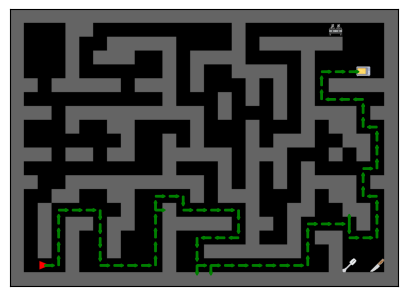

In [12]:
def first(eps): return jax.tree_map(lambda x:x[0], eps)
housemaze_analysis.render_path(first(episodes[0]))
df.head()

# Universal Successor Feature Approximators

In [13]:
from housemaze.human_dyna import sf_task_runner

task_runner_sf = sf_task_runner.TaskRunner(
    task_objects=housemaze_analysis.task_objects,
    vis_coeff=0.1,
    radius=5)
sf_env = maze.HouseMaze(
    task_runner=task_runner_sf,
    num_categories=200,
)
sf_env = utils.AutoResetWrapper(sf_env)


exp = 'exp2'
paths = f'{data_dir}/model_data/{download_data.sf_dir}/*'
paths = glob(paths)

for path in tqdm(paths):
    seed = path.split('/')[-1].split("=")[-1]
    algorithm = data_loading.load_algorithm(
        path=path,
        name='usfa',
        make_fns=functools.partial(
            housemaze_trainer.get_sf_fns,
            env=sf_env,
            env_params=dummy_env_params),
        env=sf_env,
        example_env_params=dummy_env_params,
        nenvs=nenvs,
        config=dict(EVAL_TASK_SUPPORT='train')
    )
    df, episodes = housemaze_analysis.get_algorithm_data(
        algorithm=algorithm,
        exp=exp,
        overwrite=False,
        extra_info=dict(seed=seed),
        data_task_runner=task_runner_sf,
      )
    model_df_list.append(df)
    model_episodes_list.extend(episodes)
    

  0%|          | 0/1 [00:00<?, ?it/s]

No file specified for groups.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/human_dyna/list_of_groups.npy


/var/folders/xy/l2ynyz5d10x4c52rnkln7tp80000gr/T/ipykernel_43752/2620379054.py:1: DeprecationWarning: jax.tree_map is deprecated: use jax.tree.map (jax v0.4.25 or newer) or jax.tree_util.tree_map (any JAX version).
  def first(eps): return jax.tree_map(lambda x:x[0], eps)


eval,algo,exp,room,task,maze_name,seed
bool,str,str,i64,i64,str,i64
false,"""usfa""","""exp2""",0,26,"""big_m1_maze3""",1
true,"""usfa""","""exp2""",0,40,"""big_m1_maze3""",1
false,"""usfa""","""exp2""",0,26,"""big_m2_maze2""",1
true,"""usfa""","""exp2""",0,40,"""big_m2_maze2""",1
false,"""usfa""","""exp2""",0,26,"""big_m3_maze1""",1


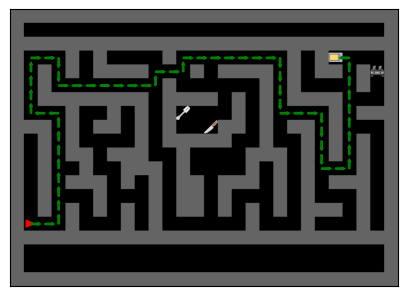

In [14]:
def first(eps): return jax.tree_map(lambda x:x[0], eps)
housemaze_analysis.render_path(first(episodes[0]))
df.head()

### Dyna-Q

In [15]:
exp = 'exp2'
# dyna_dir = f'ql/save_data/ql-21/exp={exp}'
dyna_dir = download_data.dyna_dir
paths = f'{data_dir}/model_data/{dyna_dir}/*'
paths = glob(paths)

for path in tqdm(paths):
    seed = path.split('/')[-1].split("=")[-1]
    algorithm = data_loading.load_algorithm(
        path=path,
        name='dynaq_shared',
        make_fns=functools.partial(housemaze_trainer.get_dynaq_fns,
            env=env,
            env_params=dummy_env_params,
            task_objects=housemaze_analysis.task_objects),
        env=env,
        example_env_params=dummy_env_params,
        nenvs=nenvs)
    df, episodes = housemaze_analysis.get_algorithm_data(
        algorithm=algorithm,
        exp=exp,
        overwrite=False,
        extra_info=dict(seed=seed)
      )
    model_df_list.append(df)
    model_episodes_list.extend(episodes)



  0%|          | 0/2 [00:00<?, ?it/s]

No file specified for groups.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/human_dyna/list_of_groups.npy
No file specified for groups.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/human_dyna/list_of_groups.npy


/var/folders/xy/l2ynyz5d10x4c52rnkln7tp80000gr/T/ipykernel_43752/2620379054.py:1: DeprecationWarning: jax.tree_map is deprecated: use jax.tree.map (jax v0.4.25 or newer) or jax.tree_util.tree_map (any JAX version).
  def first(eps): return jax.tree_map(lambda x:x[0], eps)


eval,algo,exp,room,task,maze_name,seed
bool,str,str,i64,i64,str,i64
false,"""dynaq_shared""","""exp2""",0,26,"""big_m3_maze1""",2
true,"""dynaq_shared""","""exp2""",0,40,"""big_m3_maze1""",2
false,"""dynaq_shared""","""exp2""",0,26,"""big_m2_maze2_onpath""",2
true,"""dynaq_shared""","""exp2""",0,40,"""big_m2_maze2_onpath""",2
false,"""dynaq_shared""","""exp2""",0,26,"""big_m2_maze2_offpath""",2


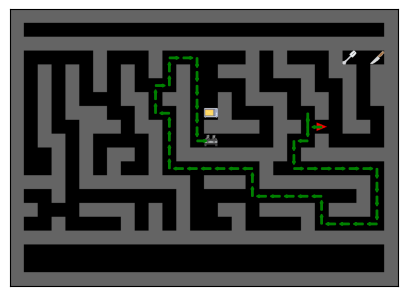

In [16]:
housemaze_analysis.render_path(first(episodes[-1]))
df.head()

### BFS/DFS

In [17]:
for algorithm in ['bfs', 'dfs']:
    df, episodes = housemaze_analysis.get_search_data(
        algorithm=algorithm,
        env=env,
        exp='exp2',
        base_path=f'{data_dir}/search_algos',
        budget=None,
        overwrite=False,
        searches=10,
      )
    model_df_list.append(df)
    model_episodes_list.extend(episodes)

No file specified for groups.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/human_dyna/list_of_groups.npy
No file specified for groups.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/human_dyna/list_of_groups.npy


/var/folders/xy/l2ynyz5d10x4c52rnkln7tp80000gr/T/ipykernel_43752/2620379054.py:1: DeprecationWarning: jax.tree_map is deprecated: use jax.tree.map (jax v0.4.25 or newer) or jax.tree_util.tree_map (any JAX version).
  def first(eps): return jax.tree_map(lambda x:x[0], eps)


eval,algo,exp,room,task,budget,maze_name
bool,str,str,i64,i64,str,str
false,"""dfs""","""exp2""",0,26,null,"""big_m1_maze3"""
true,"""dfs""","""exp2""",0,40,null,"""big_m1_maze3"""
false,"""dfs""","""exp2""",0,26,null,"""big_m2_maze2"""
true,"""dfs""","""exp2""",0,40,null,"""big_m2_maze2"""
false,"""dfs""","""exp2""",0,26,null,"""big_m3_maze1"""


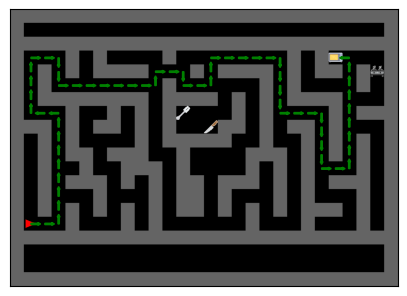

In [18]:
housemaze_analysis.render_path(first(episodes[0]))
df.head()

## put all model things together now

In [19]:
model_df = (
    pl.concat(model_df_list, how="diagonal_relaxed")
    .with_row_count(name="row_number")
    .with_columns(
        pl.col("row_number").alias("index")
    )
    .drop("row_number")
)
model_df = dataframe.DataFrame(
    df=model_df,
    episodes=model_episodes_list,
)
model_df.head()

/var/folders/xy/l2ynyz5d10x4c52rnkln7tp80000gr/T/ipykernel_43752/1099679968.py:2: DeprecationWarning: `DataFrame.with_row_count` is deprecated. Use `with_row_index` instead. Note that the default column name has changed from 'row_nr' to 'index'.
  pl.concat(model_df_list, how="diagonal_relaxed")


index,eval,algo,exp,room,task,maze_name,seed,budget
u32,bool,str,str,i64,i64,str,i64,str
0,false,"""qlearning""","""exp2""",0,26,"""big_m3_maze1""",1,null
1,true,"""qlearning""","""exp2""",0,40,"""big_m3_maze1""",1,null
2,false,"""qlearning""","""exp2""",0,26,"""big_m2_maze2_onpath""",1,null
3,true,"""qlearning""","""exp2""",0,40,"""big_m2_maze2_onpath""",1,null
4,false,"""qlearning""","""exp2""",0,26,"""big_m2_maze2_offpath""",1,null


# Human data

In [20]:
# from analysis import data_loading
# from analysis.download_data import download_user_files

# bucket_name = "human-dyna"
# prefix = "data/"
# #pattern = "data/data_user=*_name=r0-v2*debug=0.json"
# human_data_pattern = "data/data_user=*exp3*v5*debug=0.json"
# destination_folder = "/Users/wilka/git/research/results/human_dyna/user_data/exp3"

# download_user_files(bucket_name, prefix, human_data_pattern, destination_folder)

In [22]:
data_dir = '/Users/wilka/git/research/results/human_dyna/'
files = f'{data_dir}/user_data/*exp3*/*exp3*v5*t0*.json'
user_base_path = f'{data_dir}/user_data'
files = glob(files)
files, len(files)

(['/Users/wilka/git/research/results/human_dyna//user_data/exp3/data_user=2022384484_name=exp3-v5-r1-t0_exp=3_debug=0.json',
  '/Users/wilka/git/research/results/human_dyna//user_data/exp3/data_user=1020850163_name=exp3-v5-r1-t0_exp=3_debug=0.json',
  '/Users/wilka/git/research/results/human_dyna//user_data/exp3/data_user=3883429642_name=exp3-v5-r1-t0_exp=3_debug=0.json',
  '/Users/wilka/git/research/results/human_dyna//user_data/exp3/data_user=3190617625_name=exp3-v5-r1-t0_exp=3_debug=0.json',
  '/Users/wilka/git/research/results/human_dyna//user_data/exp3/data_user=3745319991_name=exp3-v5-r1-t0_exp=3_debug=0.json',
  '/Users/wilka/git/research/results/human_dyna//user_data/exp3/data_user=3707392364_name=exp3-v5-r1-t0_exp=3_debug=0.json',
  '/Users/wilka/git/research/results/human_dyna//user_data/exp3/data_user=708366916_name=exp3-v5-r1-t0_exp=3_debug=0.json',
  '/Users/wilka/git/research/results/human_dyna//user_data/exp3/data_user=398455475_name=exp3-v5-r1-t0_exp=3_debug=0.json',
  

In [23]:
web_env = SuccessTrackingAutoResetWrapper(base_env)
example_web_timestep = web_env.reset(dummy_rng, dummy_env_params)

In [24]:
# # TESTING
# import json
# file = files[1]
# with open(file, 'r') as f:
#     try:
#         data = json.load(f)
#     except Exception as e:
#         print('-'*25)
#         print(os.path.basename(file))
#         print(e)
# data_loading.make_episode_data(data=data, example_timestep=example_web_timestep, file=file)

In [25]:
# %debug 
user_df = data_loading.make_all_episode_data(
    files=files,
    example_timestep=example_web_timestep,
    overwrite=False,
    # debug=True
)
user_df.head()

/Users/wilka/miniforge3/envs/preplay/lib/python3.10/site-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()


No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
Filtered 47 data points
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
Filtered 68 data points
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
Filtered 46 data points
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
Filtered 53 data points
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
Filtered 49 data points
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
Filtered 31 data points
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/ho

Processing episodes:   0%|          | 0/77 [00:00<?, ?it/s]]

No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
Filtered 49 data points


Processing episodes:   0%|          | 0/62 [00:00<?, ?it/s]1.40it/s]

Filtered 56 data points


Processing episodes: 100%|██████████| 121/121 [10:12<00:00,  5.06s/it]


index,maze,condition,name,block,manipulation,episode_idx,eval,task,room,user_id,age,sex,exp,new_path,old_path
u32,str,i64,str,str,i64,i64,bool,i64,i64,i64,i64,str,str,bool,bool
0,"""big_m2_maze2""",0,"""big_m2_maze2""","""faster when on-path but furthe…",2,1,false,46,1,2022384484,46,"""Female""","""exp3-v5-r1-t0""",null,null
1,"""big_m2_maze2""",0,"""big_m2_maze2""","""faster when on-path but furthe…",2,2,false,31,0,2022384484,46,"""Female""","""exp3-v5-r1-t0""",null,null
2,"""big_m2_maze2""",0,"""big_m2_maze2""","""faster when on-path but furthe…",2,3,false,31,0,2022384484,46,"""Female""","""exp3-v5-r1-t0""",null,null
3,"""big_m2_maze2""",0,"""big_m2_maze2""","""faster when on-path but furthe…",2,4,false,31,0,2022384484,46,"""Female""","""exp3-v5-r1-t0""",null,null
4,"""big_m2_maze2""",0,"""big_m2_maze2""","""faster when on-path but furthe…",2,5,false,31,0,2022384484,46,"""Female""","""exp3-v5-r1-t0""",null,null


In [26]:
user_df['exp'].unique(), user_df['user_id'].unique()

(shape: (1,)
 Series: 'exp' [str]
 [
 	"exp3-v5-r1-t0"
 ],
 shape: (11,)
 Series: 'user_id' [i64]
 [
 	79671528
 	437602816
 	708366916
 	831257178
 	1020850163
 	…
 	2022384484
 	3190617625
 	3707392364
 	3745319991
 	3883429642
 ])

# Eval statistics

In [27]:
from IPython.display import Markdown, display
from analysis import housemaze
from analysis import plots
from analysis.plots import success_or_not_terminate, success

## Paths manipulation (3)

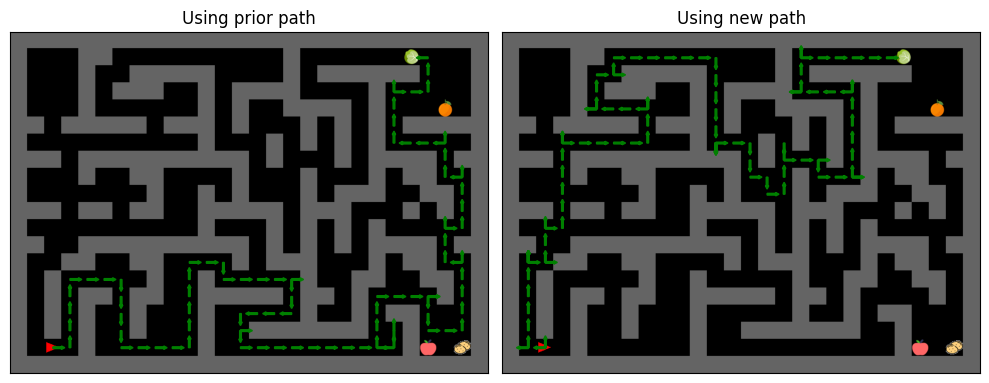

In [29]:
# plots.plot_m3_example(user_df, finished=True)
plots.plot_m3_example(user_df, finished=False)

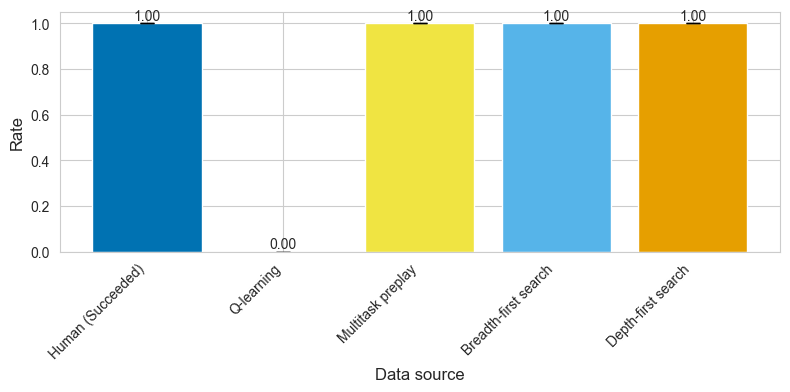

In [31]:
plots.create_success_termination_results_m3(user_df, model_df)

<Figure size 1000x600 with 0 Axes>

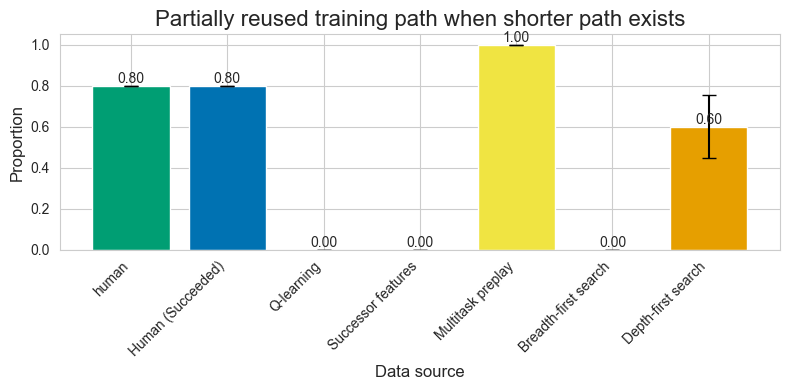

In [32]:
plots.create_bar_plot_results_m3(user_df, model_df)

/Users/wilka/git/research/human-dyna-web/analysis/plots.py:686: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=DEFAULT_LABEL_SIZE)
/Users/wilka/git/research/human-dyna-web/analysis/plots.py:686: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=DEFAULT_LABEL_SIZE)


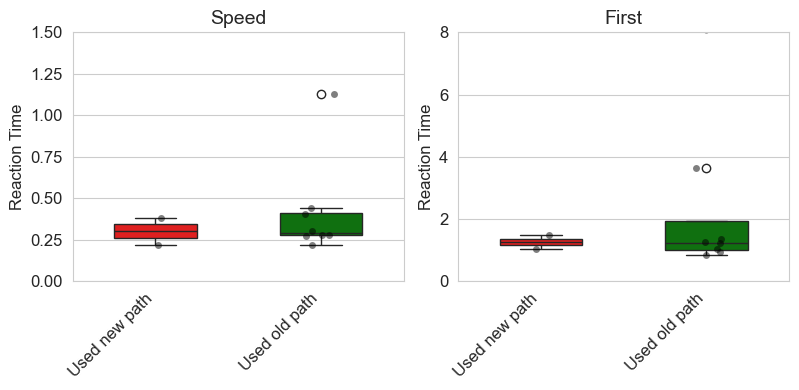

In [57]:
plots.m3_reaction_times(user_df, ylim=[[0, 1.5], [0, 8]])

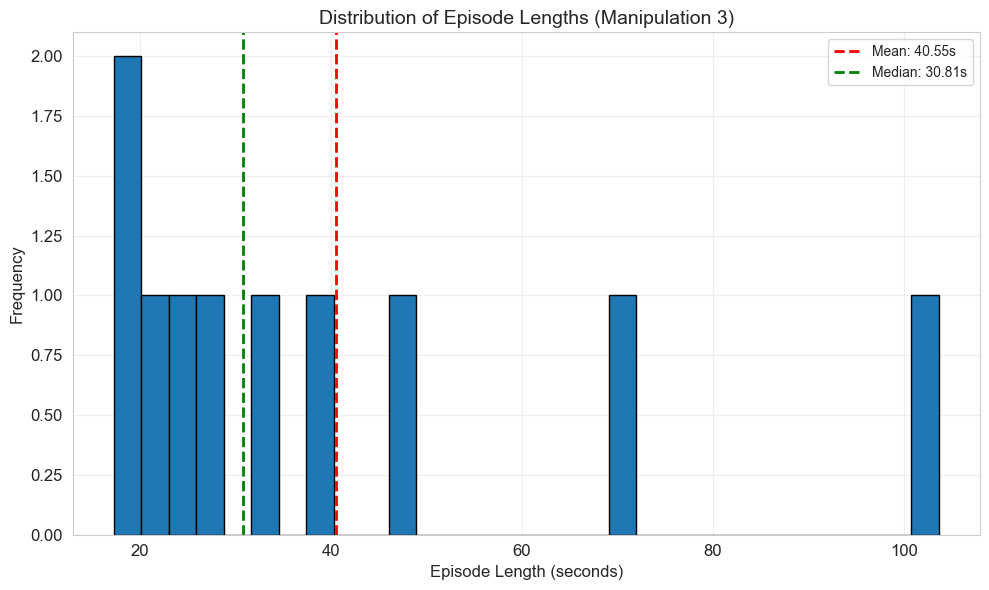

In [62]:
plots.plot_m3_episode_length_histogram(user_df)

## Starting point manipulation (2)

removed: user 831257178 rate: 0.4324324429035187 = 16/37


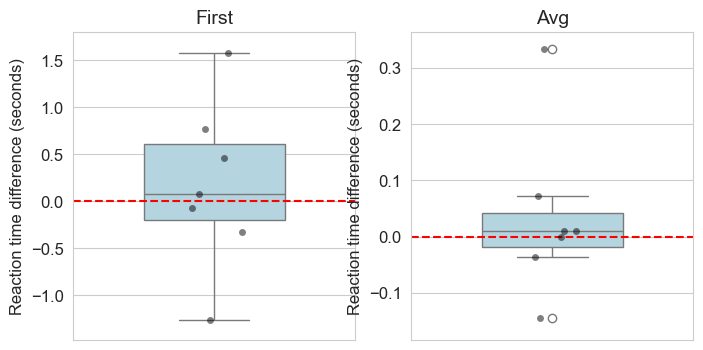

In [35]:
plots.m2_reaction_time_difference(user_df, ['first', 'avg'])

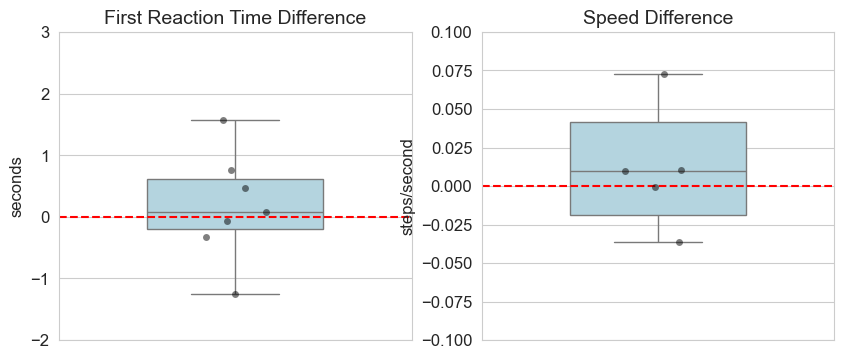

In [78]:
# fig, axs = plt.subplots(2, 1, figsize=(5, 8))
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

plots.m2_reaction_time_difference(user_df, rt_types=['first'], axs=axs[0], ylim=[-2, 3])
plots.m2_reaction_time_difference(user_df, rt_types=['avg'], axs=axs[1], ylim=[-.1, .1])

## Planning manipulation (4) - short

removed: user 79671528 rate: 0.09677419066429138 = 3/8
removed: user 1246324491 rate: 0.09677419066429138 = 3/8
removed: user 2022384484 rate: 0.12903225421905518 = 4/8
Skipping 831257178
removed: user 79671528 rate: 0.09677419066429138 = 3/8
removed: user 1246324491 rate: 0.09677419066429138 = 3/8
removed: user 2022384484 rate: 0.12903225421905518 = 4/8
Skipping 831257178


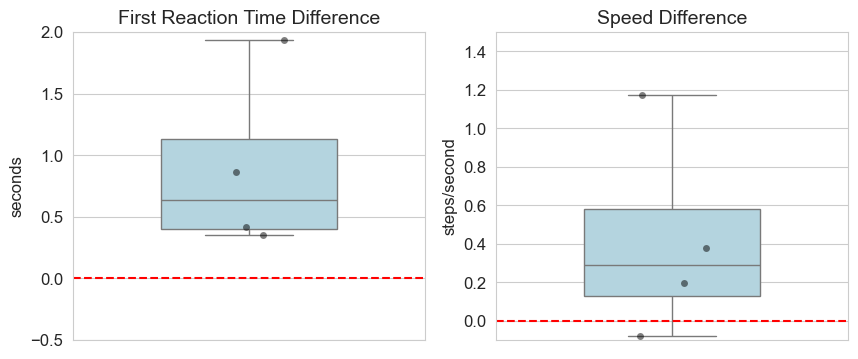

In [80]:
# fig, axs = plt.subplots(2, 1, figsize=(5, 8))
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
plots.m4_reaction_time_difference(user_df, rt_types=['first'], axs=axs[0], ylim=[-.5, 2])
plots.m4_reaction_time_difference(user_df, rt_types=['avg'], axs=axs[1], ylim=[-.1, 1.5])

removed: user 79671528 rate: 0.09677419066429138 = 3/8
removed: user 1246324491 rate: 0.09677419066429138 = 3/8
removed: user 2022384484 rate: 0.12903225421905518 = 4/8


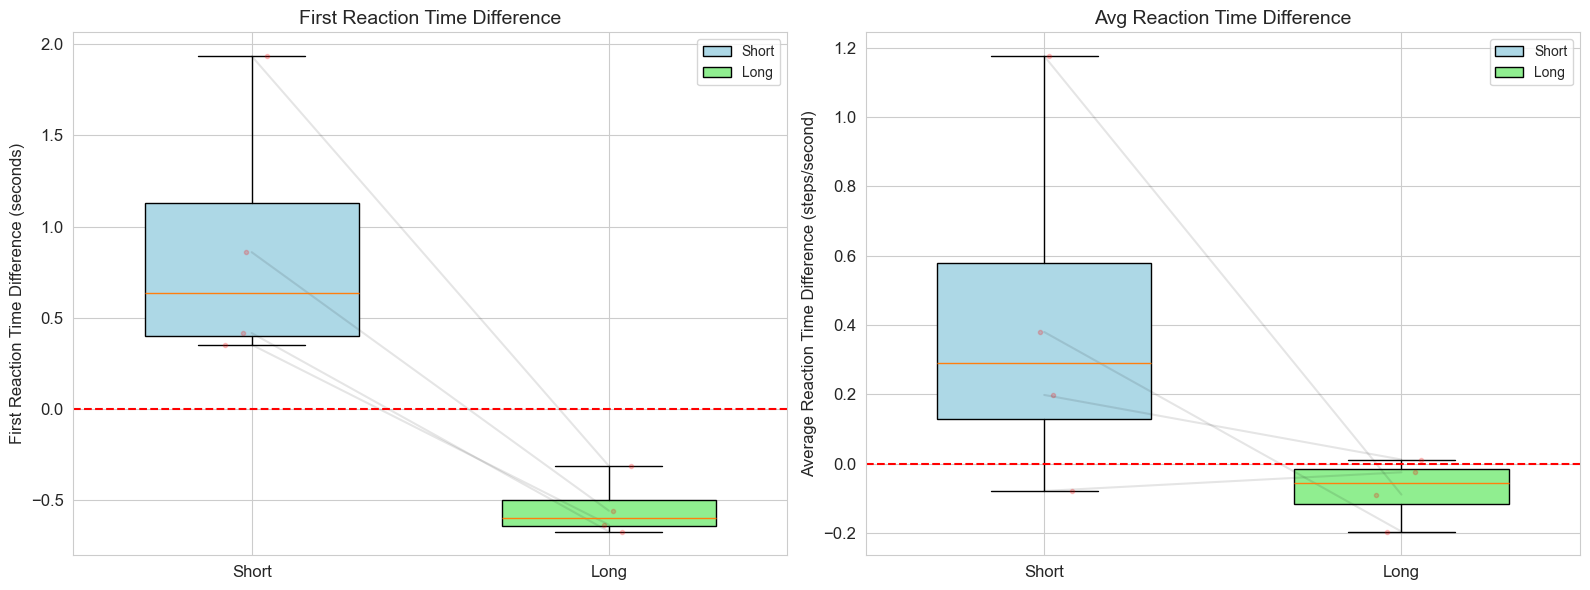

In [81]:
plots.m4_condition_reaction_times(user_df, rt_types=['first', 'avg'])

removed: user 79671528 rate: 0.09677419066429138 = 3/31
removed: user 708366916 rate: 0.42105263471603394 = 8/19
removed: user 1246324491 rate: 0.09677419066429138 = 3/31
removed: user 2022384484 rate: 0.12903225421905518 = 4/31


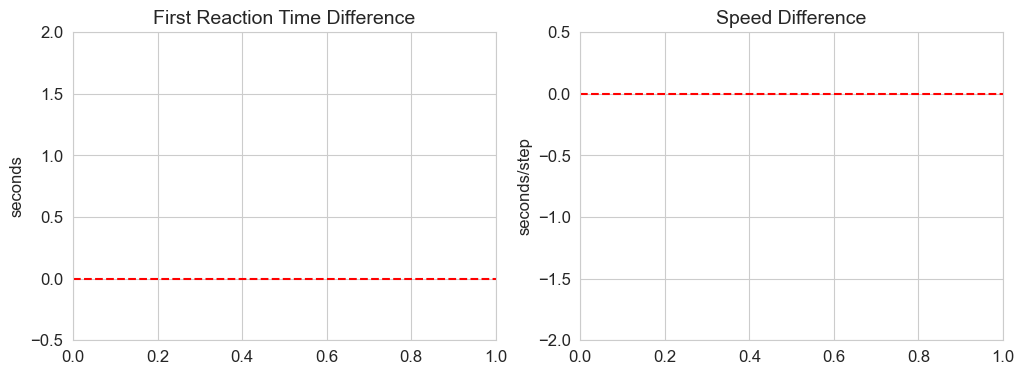

In [63]:
# plots.m4_action_reaction_time_difference(user_df, setting='short', ylim=[[-.5, 2], [-2, .5]])

removed: user 79671528 rate: 0.09677419066429138 = 3/31
removed: user 708366916 rate: 0.42105263471603394 = 8/19
removed: user 1246324491 rate: 0.09677419066429138 = 3/31
removed: user 2022384484 rate: 0.12903225421905518 = 4/31


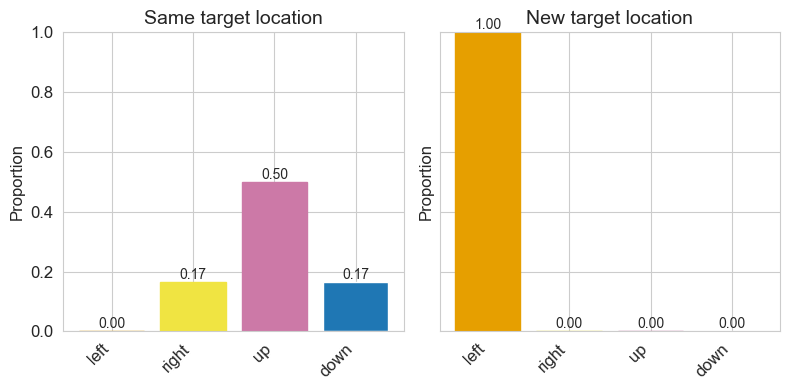

In [50]:
plots.m4_initial_action_distribution(user_df, setting='short')

removed: user 834657846 rate: 0.06451612710952759 = 2/31
removed: user 1031568544 rate: 0.12903225421905518 = 4/31
removed: user 1157239186 rate: 0.12903225421905518 = 4/31
removed: user 2675362775 rate: 0.16129031777381897 = 5/31
removed: user 3018448105 rate: 0.12903225421905518 = 4/31
removed: user 3226840500 rate: 0.09677419066429138 = 3/31


/Users/wilka/git/research/human-dyna-web/analysis/plots.py:1148: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right')
/Users/wilka/git/research/human-dyna-web/analysis/plots.py:1148: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right')


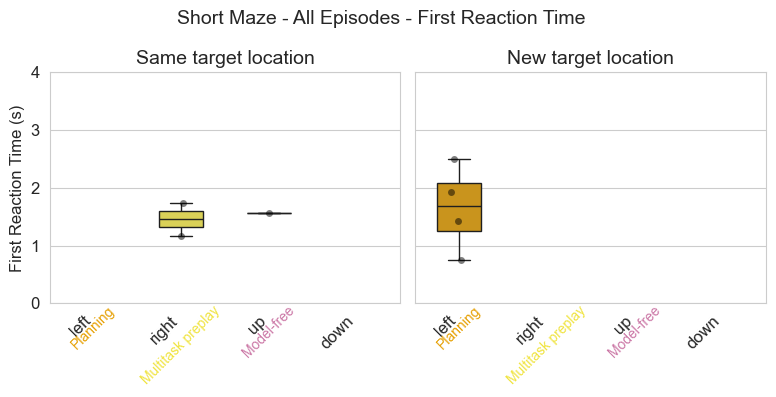

In [46]:
plots.m4_reaction_times(user_df, 'short', 'first', ylim=[0,4])

## Planning manipulation (4) - long

removed: user 2022384484 rate: 0.2666666805744171 = 8/30
removed: user 2022384484 rate: 0.2666666805744171 = 8/30


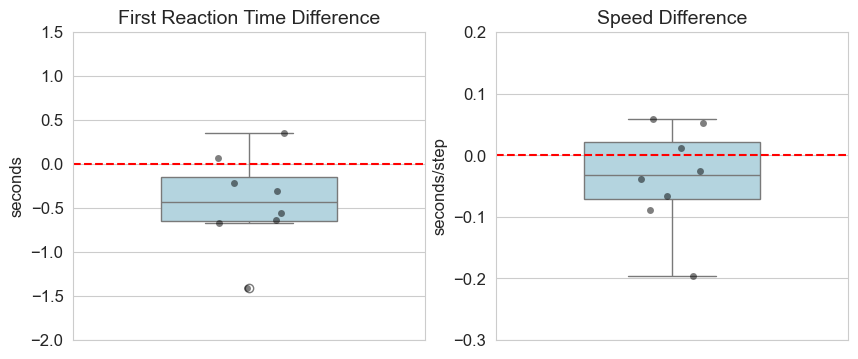

In [56]:
# fig, axs = plt.subplots(2, 1, figsize=(5, 8))
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
plots.m4_reaction_time_difference(user_df, 'long', rt_types=['first'], axs=axs[0], ylim=[-2, 1.5])
plots.m4_reaction_time_difference(user_df, 'long', rt_types=['avg'], axs=axs[1], ylim=[-.3, .2])

removed: user 2022384484 rate: 0.2666666805744171 = 8/30


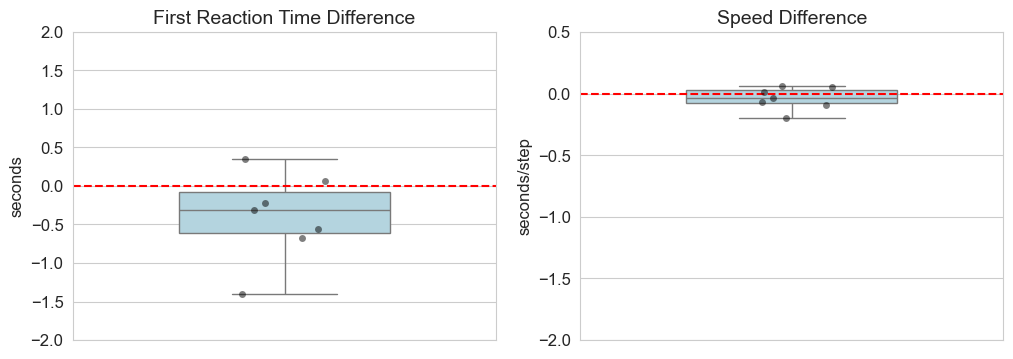

In [52]:
plots.m4_action_reaction_time_difference(user_df, setting='long', ylim=[[-2, 2], [-2, .5]])

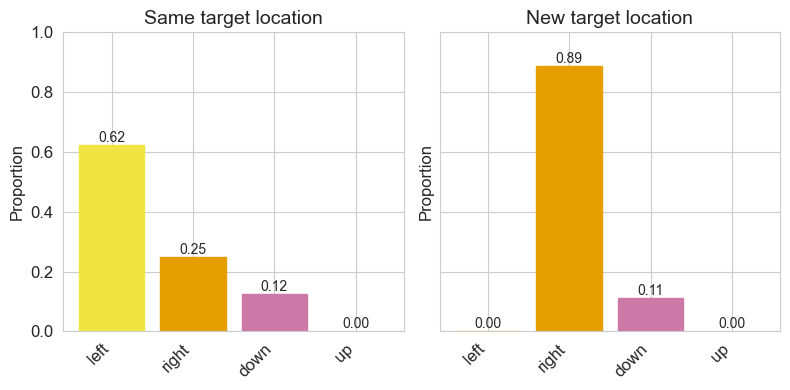

In [53]:
plots.m4_initial_action_distribution(user_df, setting='long')

# Training statistics

In [59]:
# plots.plot_train_reaction_times_dual(user_df)

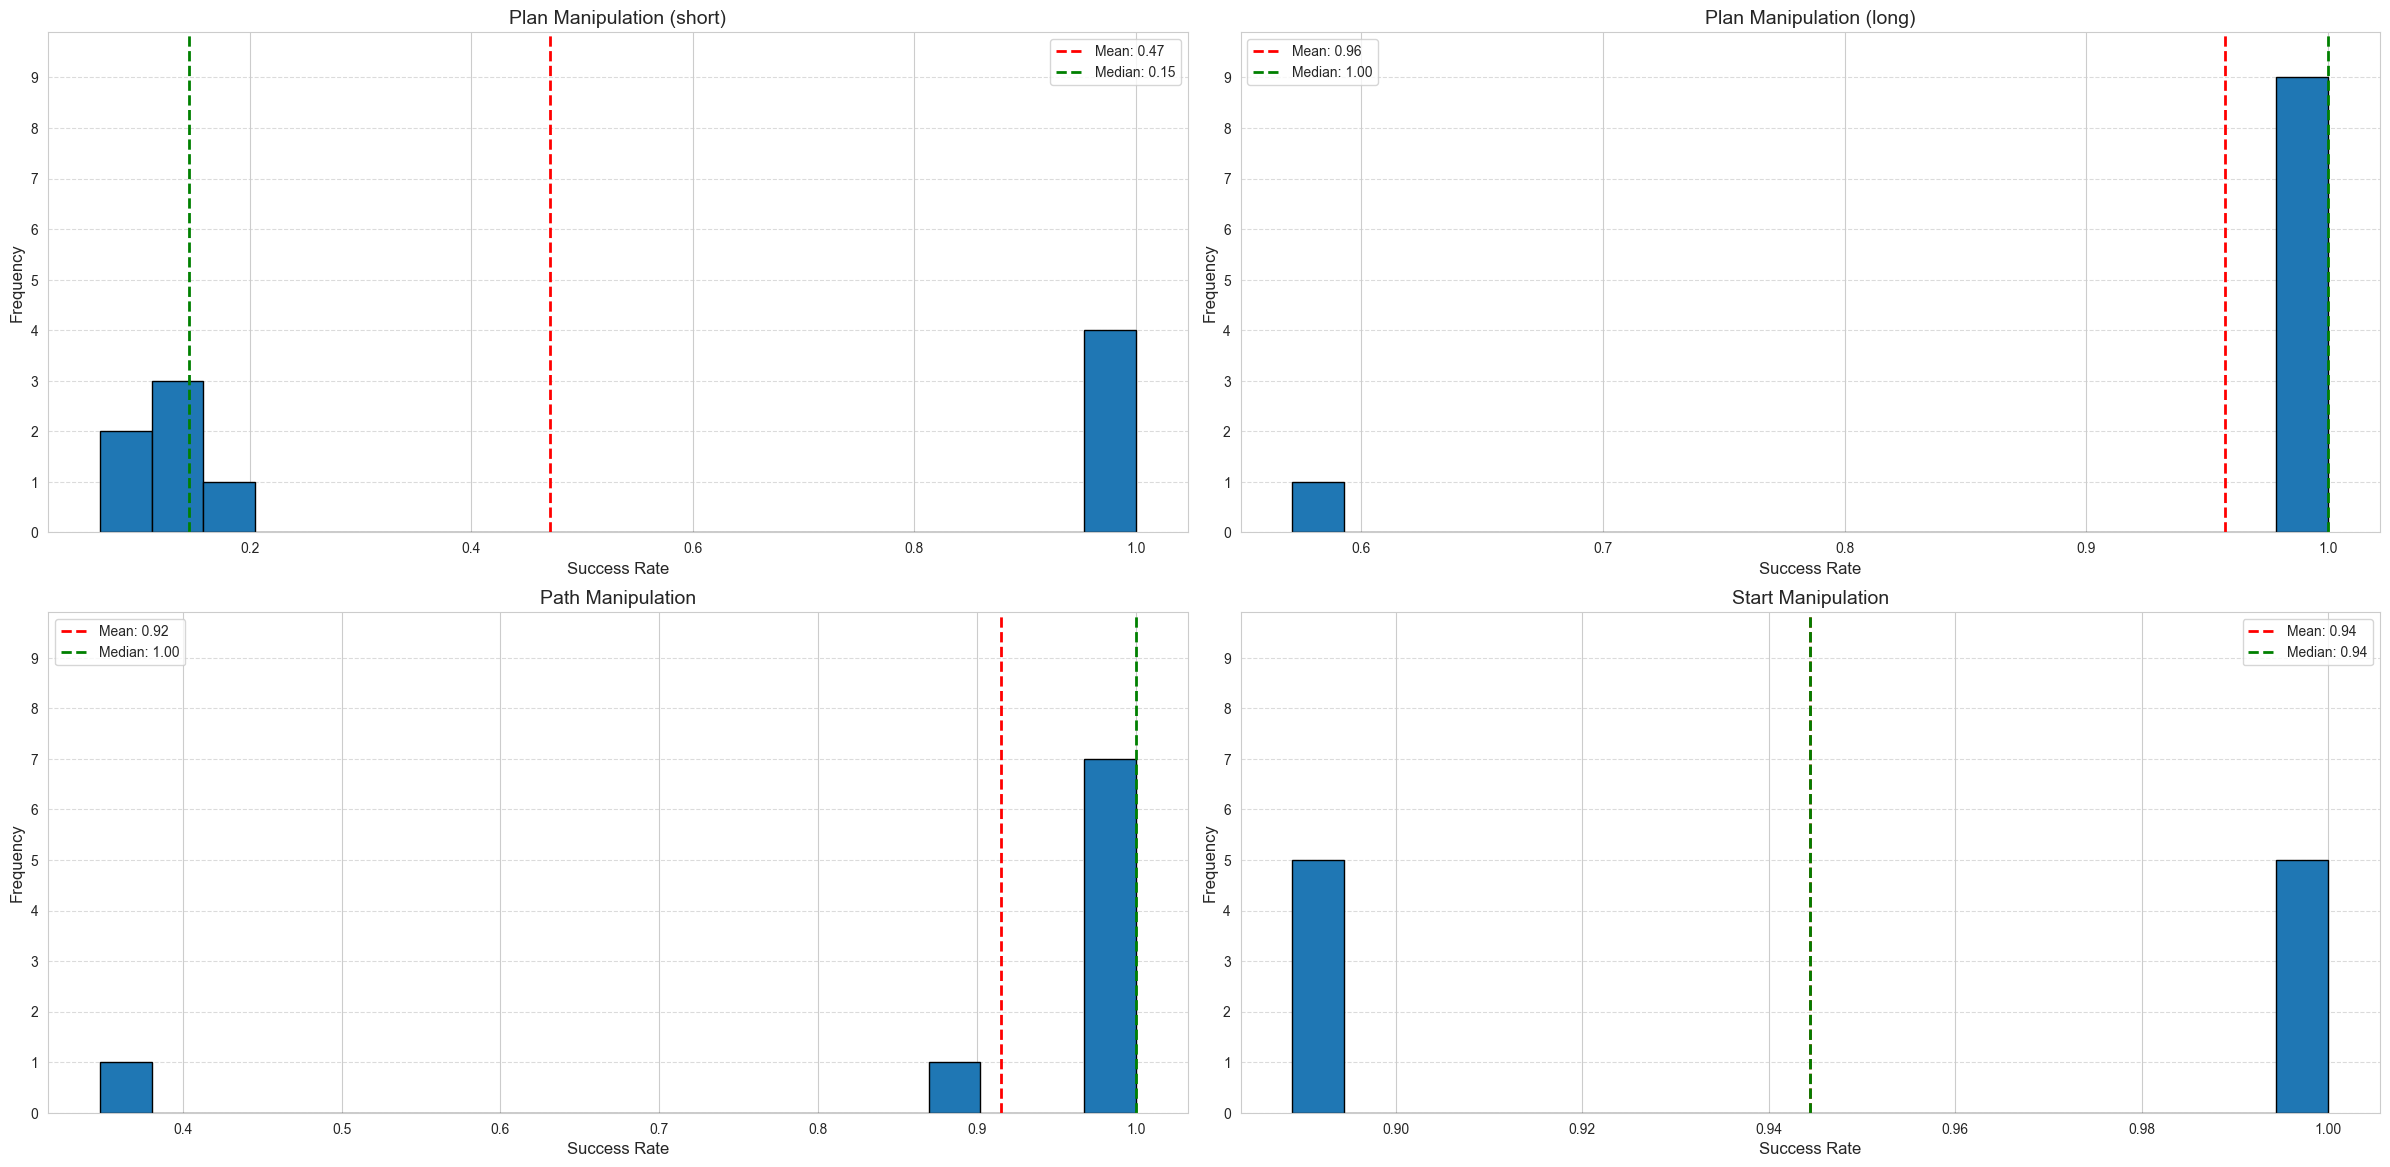

In [56]:
plots.plot_train_success_rate_histograms(user_df)

In [57]:
# plots.plot_episode_counts(user_df)

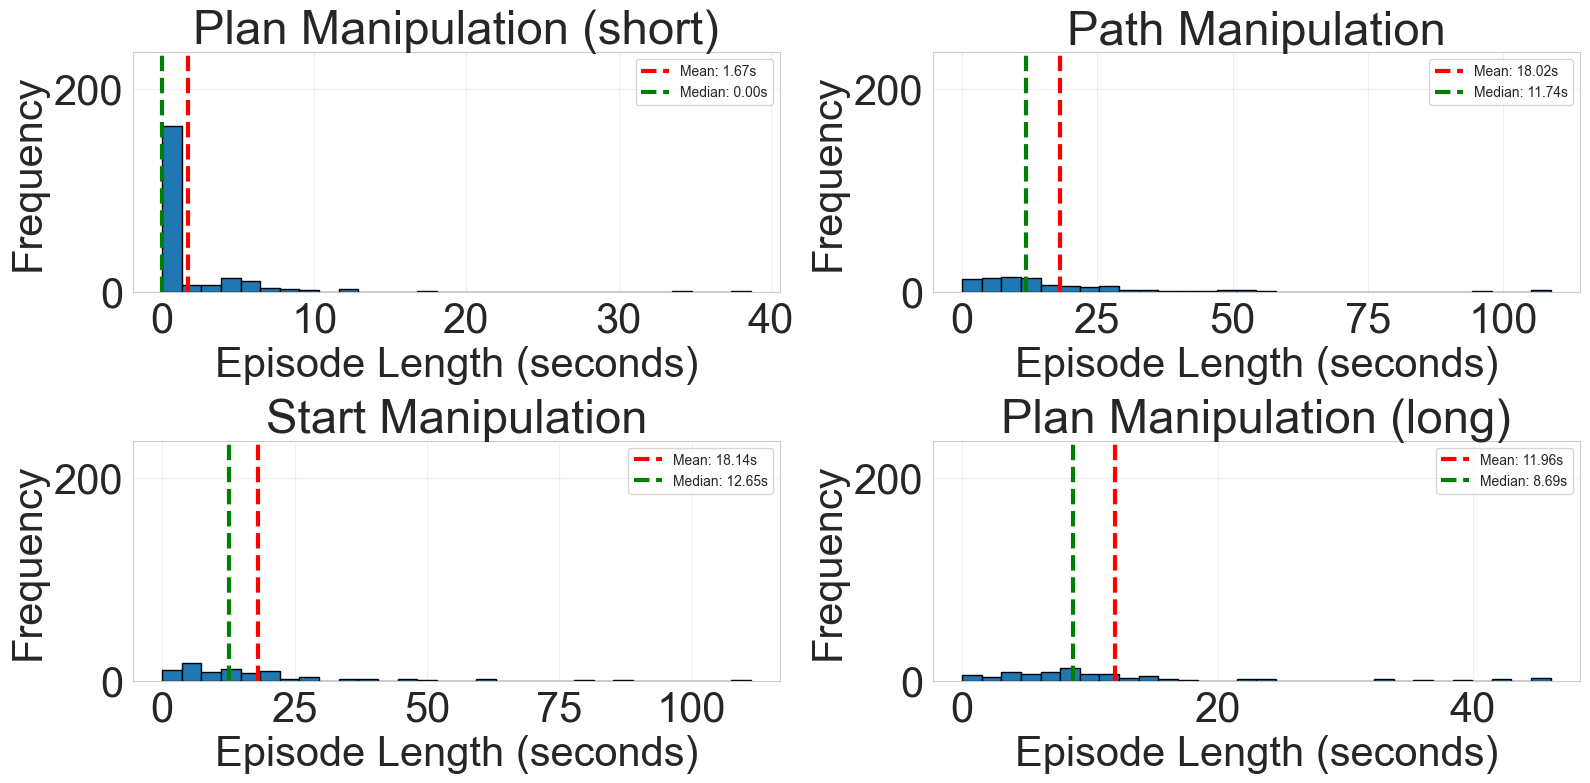

In [58]:
plots.plot_episode_length_seconds(user_df, title_size=34, label_size=30)